### Init

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import fhd
import importlib
import time
import math
from pathlib import Path 
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib as mpl
import pyogrio
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator
from scipy.optimize import lsq_linear
from shapely.geometry import box
import re
from collections import defaultdict

importlib.reload(fhd)

<module 'fhd' from 'c:\\Users\\rmosk\\Dropbox\\Rinske\\Computational Science\\A Scriptie\\fluctuating_hydro\\fhd\\__init__.py'>

In [5]:
plt.rcParams['font.family'] = 'serif'

title_size = 16
title_size_subplots = 18
ax_size = 14

species = ["low income", "middel income", "high income"]
species_colors = ["red", "green", "blue"]
bar_colors = ["darkred", "darkgreen", "darkblue"]
cmap_colors = ["Reds", "Greens", "Blues"]

In [6]:
# Path to the data directory
DATA_DIR = Path("C:\\Users\\rmosk\\Dropbox\\Rinske\\Computational Science\\A Scriptie\\fluctuating_hydro\\CBS_data")

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2020_vol.gpkg"

# Read the geopackage
gdf_2020 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2019_vol2.gpkg"

# Read the geopackage
gdf_2019 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2018.gpkg"

# Read the geopackage
gdf_2018 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2017.gpkg"

# Read the geopackage
gdf_2017 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2016_v2.shp"

# Read the geopackage
gdf_2016 = gpd.read_file(gpkg_path)

gdf_2016.to_file(
    DATA_DIR / "cbs_vk500_2016_v2.gpkg",
    driver="GPKG"
)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2015_v2.shp"

# Read the geopackage
gdf_2015 = gpd.read_file(gpkg_path)

gdf_2015.to_file(
    DATA_DIR / "cbs_vk500_2015_v2.gpkg",
    driver="GPKG"
)

old_path = DATA_DIR / "1971-2017" / "CBSvierkant500m_19712014_201711.shp"

gdf_1971_2014 = gpd.read_file(old_path)

gdf_1971_2014.to_file(
    DATA_DIR / "CBSvierkant500m_19712014_201711.gpkg",
    driver="GPKG"
)

area_path = DATA_DIR / "gebieds_indelingen" / "cbsgebiedsindelingen2020.gpkg"

# areas = gpd.read_file(area_path)
layers = pyogrio.list_layers(area_path)

inw_path = DATA_DIR / "max_inwoners_2000_2020.gpkg"

inw_gdf = gpd.read_file(inw_path)

In [7]:
gemeenten = gpd.read_file(
    area_path,
    layer="gemeente_niet_gegeneraliseerd"
)

In [8]:
gemeenten = gpd.read_file(
    area_path,
    layer="gemeente_niet_gegeneraliseerd"
)

corop = gpd.read_file(
    area_path,
    layer= "coropgebied_gegeneraliseerd"
)

gdf_2020_clean = gdf_2020.copy()
num_cols = gdf_2020_clean.select_dtypes(include="number").columns
gdf_2020_clean[num_cols] = gdf_2020_clean[num_cols].mask(gdf_2020[num_cols] < -90000, np.nan)

gdf_2019_clean = gdf_2019.copy()
num_cols = gdf_2019_clean.select_dtypes(include="number").columns
gdf_2019_clean[num_cols] = gdf_2019_clean[num_cols].mask(gdf_2019[num_cols] < -90000, np.nan)

gdf_2018_clean = gdf_2018.copy()
num_cols = gdf_2018_clean.select_dtypes(include="number").columns
gdf_2018_clean[num_cols] = gdf_2018_clean[num_cols].mask(gdf_2018[num_cols] < -90000, np.nan)

gdf_2017_clean = gdf_2017.copy()
num_cols = gdf_2017_clean.select_dtypes(include="number").columns
gdf_2017_clean[num_cols] = gdf_2017_clean[num_cols].mask(gdf_2017[num_cols] < -90000, np.nan)

gdf_2016_clean = gdf_2016.copy()
num_cols = gdf_2016_clean.select_dtypes(include="number").columns
gdf_2016_clean[num_cols] = gdf_2016_clean[num_cols].mask(gdf_2016[num_cols] < -90000, np.nan)

gdf_2015_clean = gdf_2015.copy()
num_cols = gdf_2015_clean.select_dtypes(include="number").columns
gdf_2015_clean[num_cols] = gdf_2015_clean[num_cols].mask(gdf_2015[num_cols] < -90000, np.nan)

gdf_1971_2014_clean = gdf_1971_2014.copy()
num_cols = gdf_1971_2014_clean.select_dtypes(include="number").columns
gdf_1971_2014_clean[num_cols] = gdf_1971_2014_clean[num_cols].mask(gdf_1971_2014[num_cols] < -90000, np.nan)

inw_gdf_clean = inw_gdf.copy()
num_cols = inw_gdf_clean.select_dtypes(include="number").columns
inw_gdf_clean[num_cols] = inw_gdf_clean[num_cols].mask(inw_gdf_clean[num_cols] < -90000, np.nan)

inw_gdf = inw_gdf_clean

In [ ]:
corop_names_dh = [
    "Agglomeratie 's-Gravenhage",
    "Delft en Westland",
    "Groot-Rijnmond",
]

corop_names_u = ["Utrecht"]

corop_names_a = ["Groot-Amsterdam"]

cols = [ 
    ("aantal_inwoners", "INWONER","INW2011", "INW2012", "INW2013", "INW2014", "Aantal inwoners"),
    # ("aantal_part_huishoudens", "Aantal huishoudens", " "),
    ("percentage_laag_inkomen_huishouden", "P_LINK_HH","P_LINH2011", "P_LINH2012", "P_LINH2013", "P_LINH2014", "Laag inkomen"),
    ("percentage_midden_inkomen_huishouden", "P_MINK_HH","P_MIDDEL2011", "P_MIDDEL2012", "P_MIDDEL2013", "P_MIDDEL2014", "Midden inkomen"),
    ("percentage_hoog_inkomen_huishouden", "P_HINK_HH","P_HINH2011", "P_HINH2012", "P_HINH2013", "P_HINH2014", "Hoog inkomen"),
    ("aantal_woningen", "WONING"),
    ("aantal_niet_bewoonde_woningen", "WON_NBEW"),
    ("gemiddelde_woz_waarde_woning", "WOZWONING"),
]

dhr_gdf_reduced_2015, bounds_dhr, gemeenten_clipped_2015_dhr = fhd.crop_and_rescale_rdh(
    year=2015,
    gdf=gdf_2015_clean,
    corop_gdf=corop,
    corop_names=corop_names_dh,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2015, bounds_ut, gemeenten_clipped_2015_ut = fhd.crop_and_rescale(
    year=2015,
    gdf=gdf_2015_clean,
    corop_gdf=corop,
    corop_names=corop_names_u,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ams_gdf_reduced_2015, bounds_ams, gemeenten_clipped_2015_ams = fhd.crop_and_rescale(
    year=2015,
    gdf=gdf_2015_clean,
    corop_gdf=corop,
    corop_names=corop_names_a,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

dhr_gdf_reduced_2016, bounds_dhr, gemeenten_clipped_2016_dhr = fhd.crop_and_rescale_rdh(
    year=2016,
    gdf=gdf_2016_clean,
    corop_gdf=corop,
    corop_names=corop_names_dh,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2016, bounds_ut, gemeenten_clipped_2016_ut = fhd.crop_and_rescale(
    year=2016,
    gdf=gdf_2016_clean,
    corop_gdf=corop,
    corop_names=corop_names_u,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ams_gdf_reduced_2016, bounds_ams, gemeenten_clipped_2016_ams = fhd.crop_and_rescale(
    year=2016,
    gdf=gdf_2016_clean,
    corop_gdf=corop,
    corop_names=corop_names_a,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

C:\Users\rmosk\AppData\Local\Temp\ipykernel_28268\2870659784.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


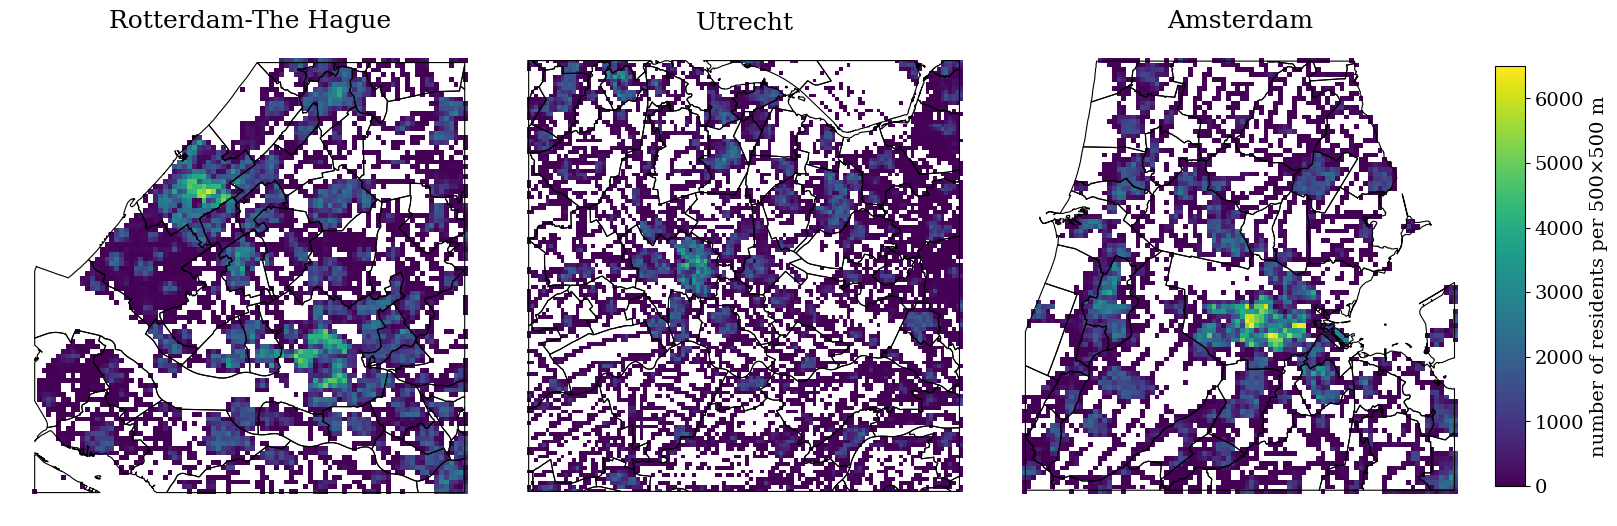

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

datas = [dhr_gdf_reduced_2015, ut_gdf_reduced_2015, ams_gdf_reduced_2015]
areas = ["Rotterdam-The Hague", "Utrecht", "Amsterdam"]
gemeenten_all  = [gemeenten_clipped_2015_dhr, gemeenten_clipped_2015_ut, gemeenten_clipped_2015_ams]
bounds = [bounds_dhr, bounds_ut, bounds_ams]

plot = None
norm = None
cmap = "viridis"

for i, data in enumerate(datas):
    minx, miny, maxx, maxy = bounds[i]

    # Create a bounding box polygon for clipping
    bbox = box(minx, miny, maxx, maxy)

    # Clip the gemeenten geometries to the bounding box
    gemeenten_clipped = gemeenten_all[i].copy()
    gemeenten_clipped.geometry = gemeenten_clipped.geometry.intersection(bbox)

    plot = data.plot(
    column="INWONER",
    ax=axes[i],
    cmap="viridis",
    legend=False,
    vmax = 6500,
    vmin = 0,
    )
    if i == 0:
        norm = plot.collections[0].norm
    gemeenten_clipped.boundary.plot(ax=axes[i], color="black", linewidth=0.8)

    axes[i].set_title(f"{areas[i]}", fontsize=title_size_subplots)
    axes[i].axis("off")
    
plt.subplots_adjust(right=0.85)

# Add a single colorbar to the right of the subplots
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(plot.collections[0], cax=cbar_ax)
cbar.ax.tick_params(labelsize=ax_size) 
cbar.set_label("number of residents per 500×500 m", fontsize=ax_size)

plt.tight_layout()
# plt.suptitle("Residents per 500x500")
plt.show()

In [12]:
print(dhr_gdf_reduced_2016['WOZWONING'].max())
print(ut_gdf_reduced_2016['WOZWONING'].max())
print(ams_gdf_reduced_2016['WOZWONING'].max())

2338.0
2968.0
2425.0


C:\Users\rmosk\AppData\Local\Temp\ipykernel_28268\573700398.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


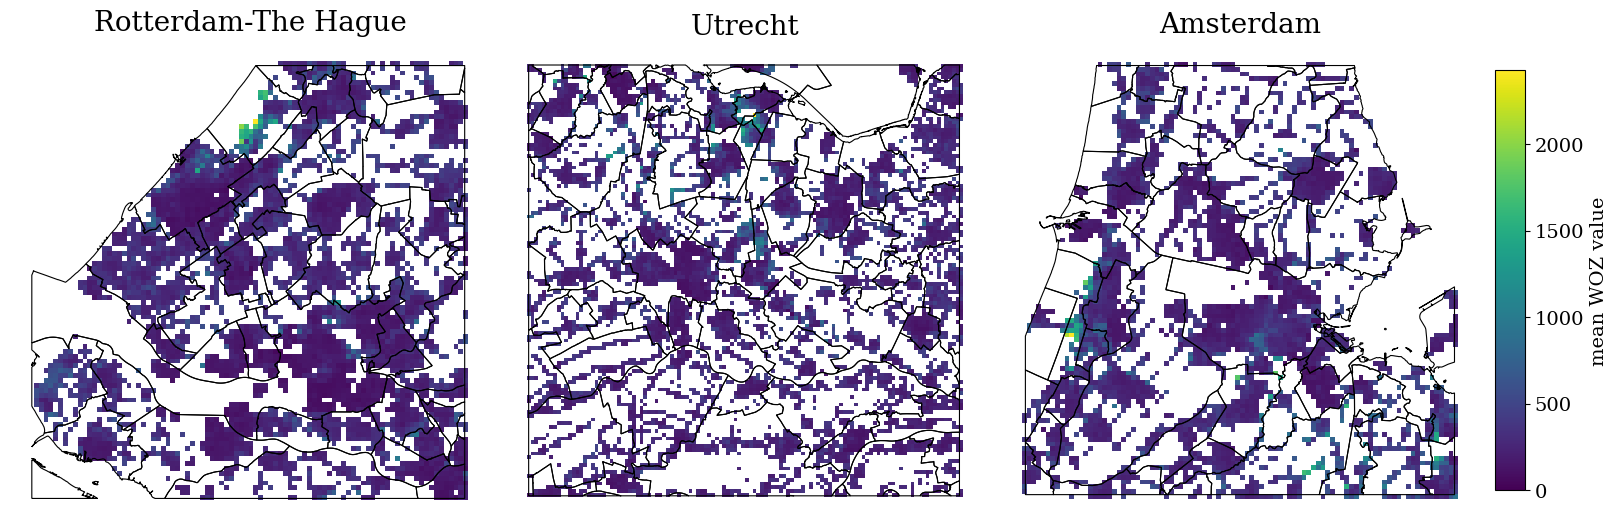

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

datas = [dhr_gdf_reduced_2016, ut_gdf_reduced_2016, ams_gdf_reduced_2016]
areas = ["Rotterdam-The Hague", "Utrecht", "Amsterdam"]
gemeenten_all  = [gemeenten_clipped_2016_dhr, gemeenten_clipped_2016_ut, gemeenten_clipped_2016_ams]
bounds = [bounds_dhr, bounds_ut, bounds_ams]

plot = None
norm = None
cmap = "viridis"

for i, data in enumerate(datas):
    minx, miny, maxx, maxy = bounds[i]

    # Create a bounding box polygon for clipping
    bbox = box(minx, miny, maxx, maxy)

    # Clip the gemeenten geometries to the bounding box
    gemeenten_clipped = gemeenten_all[i].copy()
    gemeenten_clipped.geometry = gemeenten_clipped.geometry.intersection(bbox)

    plot = data.plot(
    column="WOZWONING",
    ax=axes[i],
    cmap="viridis",
    # legend=True,
    # vmax = 1000,
    vmin = 0,
    # legend_kwds={"label": "mean WOZ value per 500×500 m"},
    # cbar_kwds = {"shrink": 0.75} if i == 2 else {"shrink": 0},
    # extent=[minx, maxx, miny, maxy], 
    )
    if i == 0:
        norm = plot.collections[0].norm
    gemeenten_clipped.boundary.plot(ax=axes[i], color="black", linewidth=0.8)

    axes[i].set_title(f"{areas[i]}", fontsize=title_size_subplots+2)
    axes[i].axis("off")
    
plt.subplots_adjust(right=0.85)

# Add a single colorbar to the right of the subplots
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(plot.collections[0], cax=cbar_ax)
cbar.ax.tick_params(labelsize=ax_size) 
cbar.set_label("mean WOZ value", fontsize=ax_size)

plt.tight_layout()
# plt.suptitle("Residents per 500x500")
plt.show()

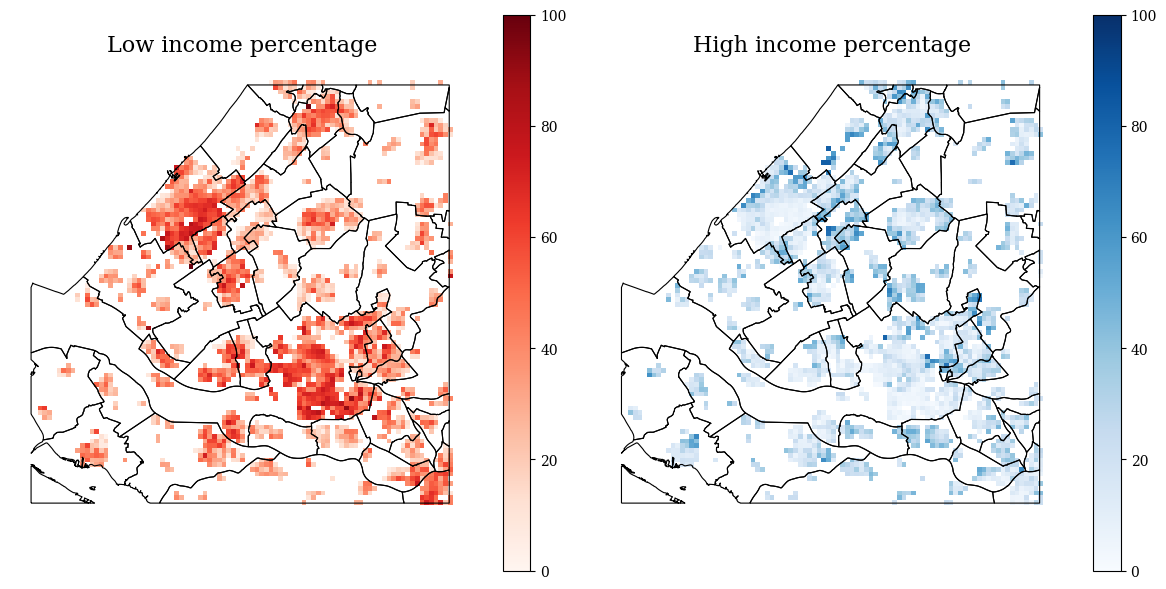

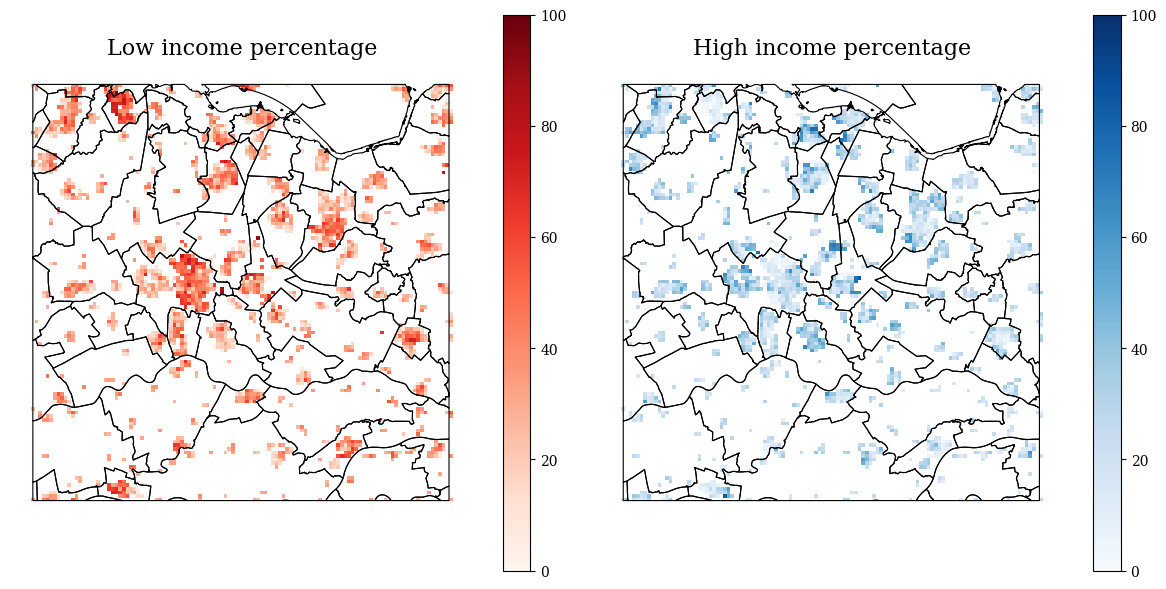

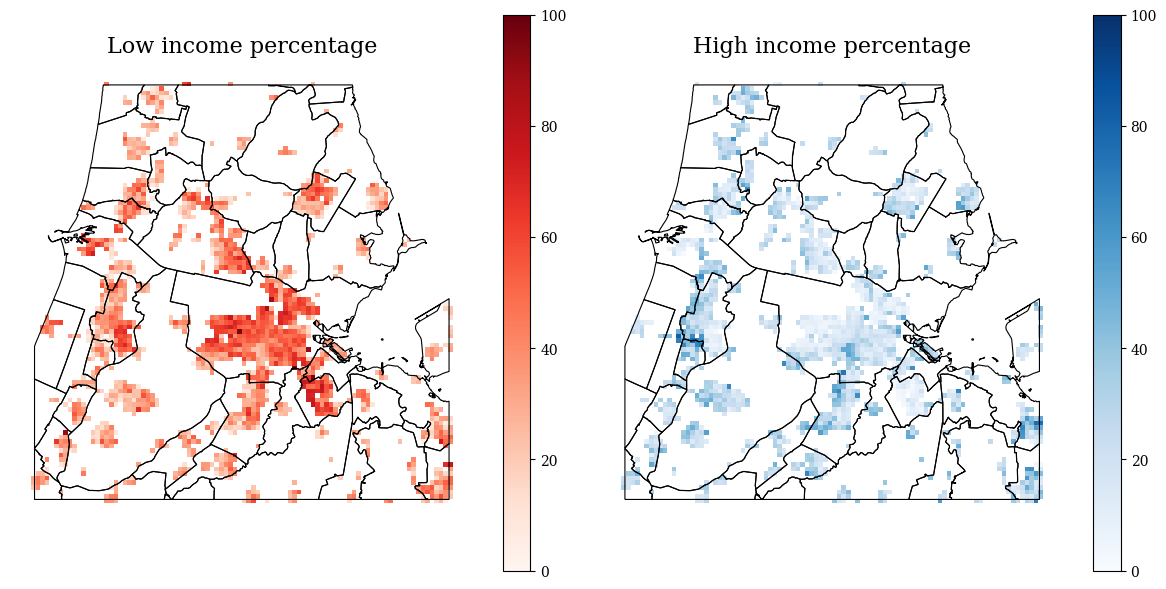

In [33]:
datas = [dhr_gdf_reduced_2015, ut_gdf_reduced_2015, ams_gdf_reduced_2015]
areas = ["Rotterdam-The Hague", "Utrecht", "Amsterdam"]
gemeenten_all  = [gemeenten_clipped_2015_dhr, gemeenten_clipped_2015_ut, gemeenten_clipped_2015_ams]
bounds = [bounds_dhr, bounds_ut, bounds_ams]



for i, data in enumerate(datas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    minx, miny, maxx, maxy = bounds[i]

    # Create a bounding box polygon for clipping
    bbox = box(minx, miny, maxx, maxy)

    # Clip the gemeenten geometries to the bounding box
    gemeenten_clipped = gemeenten_all[i].copy()
    gemeenten_clipped.geometry = gemeenten_clipped.geometry.intersection(bbox)

    plot1 = data.plot(
        column="P_LINK_HH",
        ax=axes[0],
        cmap = cmap_colors[0],
        legend=True,
        vmin = 0,
        vmax = 100,
    )
    axes[0].set_title(f"Low income percentage", fontsize=title_size)
    gemeenten_clipped.boundary.plot(ax=axes[0], color="black", linewidth=0.8)

    # cbar1 = fig.colorbar(plot1, ax=axes[0], shrink=0.6, aspect=10)
    # cbar1.set_label("Percentage")

    data.plot(
        column="P_HINK_HH",
        ax=axes[1],
        cmap = cmap_colors[2],
        legend=True,
        vmax = 100,
        vmin = 0,
    )
    axes[1].set_title(f"High income percentage", fontsize=title_size)
    gemeenten_clipped.boundary.plot(ax=axes[1], color="black", linewidth=0.8)

    axes[0].axis("off")
    axes[1].axis("off")
    
    # fig.suptitle(f"{areas[i]}", fontsize=title_size, axes = axes[i])
    # fig.text(0.5, 0.97 - i * 0.32, areas[i],
    #          ha='center', va='center', fontsize=title_size+2)


    plt.tight_layout()
    # plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.subplots_adjust(hspace=0.3)
    plt.show()

    


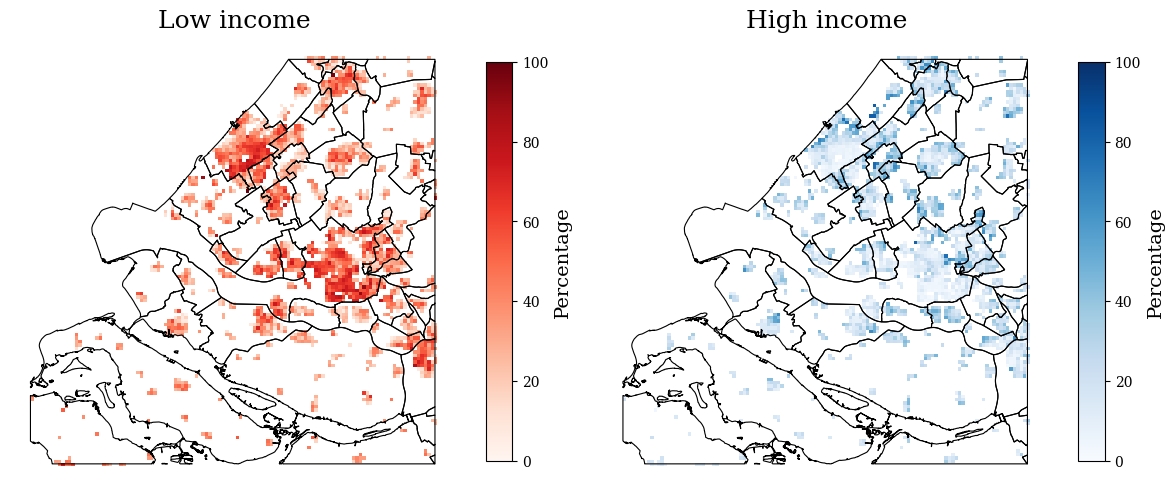

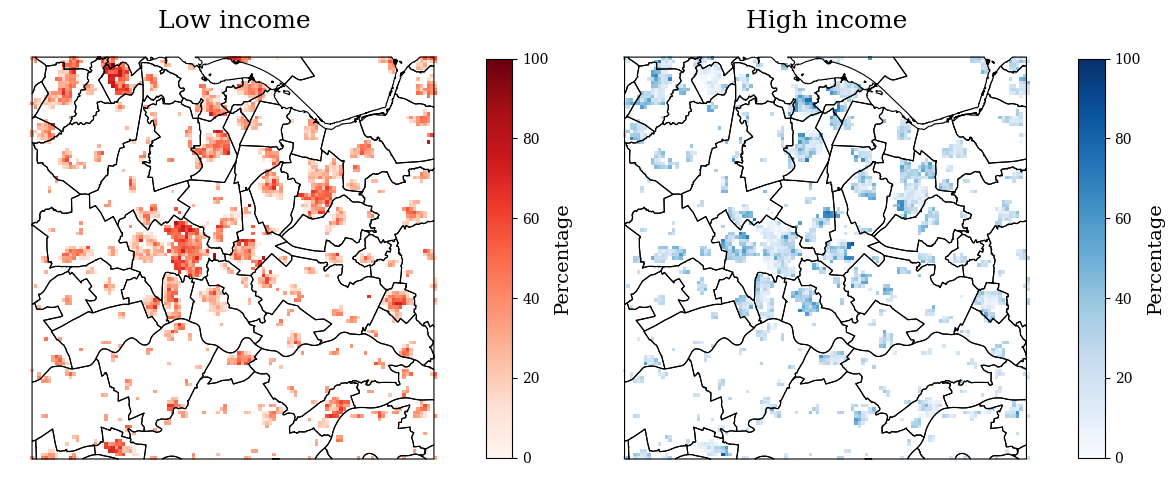

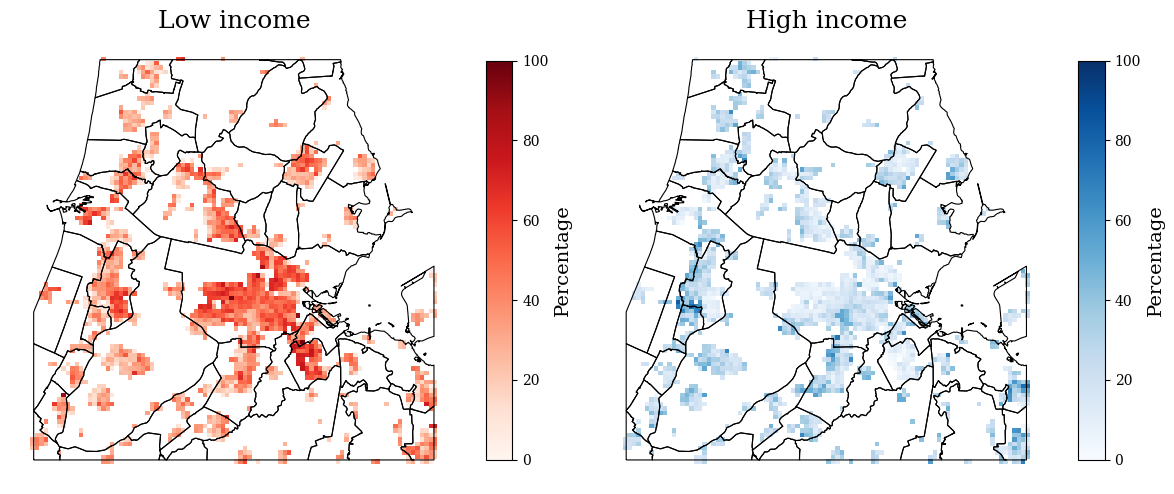

In [28]:
for i, data in enumerate(datas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    minx, miny, maxx, maxy = bounds[i]

    # Create a bounding box polygon for clipping
    bbox = box(minx, miny, maxx, maxy)

    # Clip the gemeenten geometries to the bounding box
    gemeenten_clipped = gemeenten_all[i].copy()
    gemeenten_clipped.geometry = gemeenten_clipped.geometry.intersection(bbox)

    # Plot for low income percentage
    plot1 = data.plot(
        column="P_LINK_HH",
        ax=axes[0],
        cmap=cmap_colors[0],
        vmin=0,
        vmax=100,
        legend=False,  # Disable automatic legend
    )
    axes[0].set_title(f"Low income", fontsize=title_size+2)
    gemeenten_clipped.boundary.plot(ax=axes[0], color="black", linewidth=0.8)

    # Get the ScalarMappable object from the plot
    sm1 = plt.cm.ScalarMappable(cmap=cmap_colors[0], norm=plt.Normalize(vmin=0, vmax=100))
    sm1.set_array([])
    cbar1 = fig.colorbar(sm1, ax=axes[0], shrink=0.7, aspect=15)
    cbar1.set_label("Percentage", fontsize = ax_size)

    # Plot for high income percentage
    plot2 = data.plot(
        column="P_HINK_HH",
        ax=axes[1],
        cmap=cmap_colors[2],
        vmin=0,
        vmax=100,
        legend=False,  # Disable automatic legend
    )
    axes[1].set_title(f"High income", fontsize=title_size+2)
    gemeenten_clipped.boundary.plot(ax=axes[1], color="black", linewidth=0.8)

    # Get the ScalarMappable object for the second plot
    sm2 = plt.cm.ScalarMappable(cmap=cmap_colors[2], norm=plt.Normalize(vmin=0, vmax=100))
    sm2.set_array([])
    cbar2 = fig.colorbar(sm2, ax=axes[1], shrink=0.7, aspect=15)
    cbar2.set_label("Percentage", fontsize = ax_size)

    axes[0].axis("off")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [35]:
cell_size = 500
n = int(bounds_dhr[2]-bounds_dhr[0]) // cell_size

ns = 3
N = (n, n)
Lx, Ly = (50,50)
dx = Lx/n
dy = Ly/n

x = np.arange(-Lx/2, Lx/2, dx)
y = np.arange(-Ly/2, Ly/2, dy)

minx, miny, maxx, maxy = bounds_dhr

phi_rdh_2015 = np.full((ns, len(y), len(x)), np.nan)


centroids = dhr_gdf_reduced_2015.geometry.centroid

cols = ((centroids.x - minx) // cell_size).astype(int)
rows = ((centroids.y - miny) // cell_size).astype(int)

cols = np.clip(cols, 0, len(x)-1)
rows = np.clip(rows, 0, len(y)-1)

cols_inc = [ 
    ("percentage_laag_inkomen_huishouden", "P_LINK_HH","P_LINH2011", "P_LINH2012", "P_LINH2013", "P_LINH2014", "Laag inkomen"),
    ("percentage_midden_inkomen_huishouden", "P_MINK_HH","P_MIDDEL2011", "P_MIDDEL2012", "P_MIDDEL2013", "P_MIDDEL2014", "Midden inkomen"),
    ("percentage_hoog_inkomen_huishouden", "P_HINK_HH","P_HINH2011", "P_HINH2012", "P_HINH2013", "P_HINH2014", "Hoog inkomen"),
]

cols_inw = ["aantal_inwoners", "INWONER","INW2011", "INW2012", "INW2013", "INW2014", "Aantal inwoners"]

inx = 1

# 2015
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_rdh_2015[i, rows, cols] = dhr_gdf_reduced_2015[col_name].fillna(np.nan) / 100

mirror_2015, nan_mask_2015 = fhd.mirrorred(phi_rdh_2015)

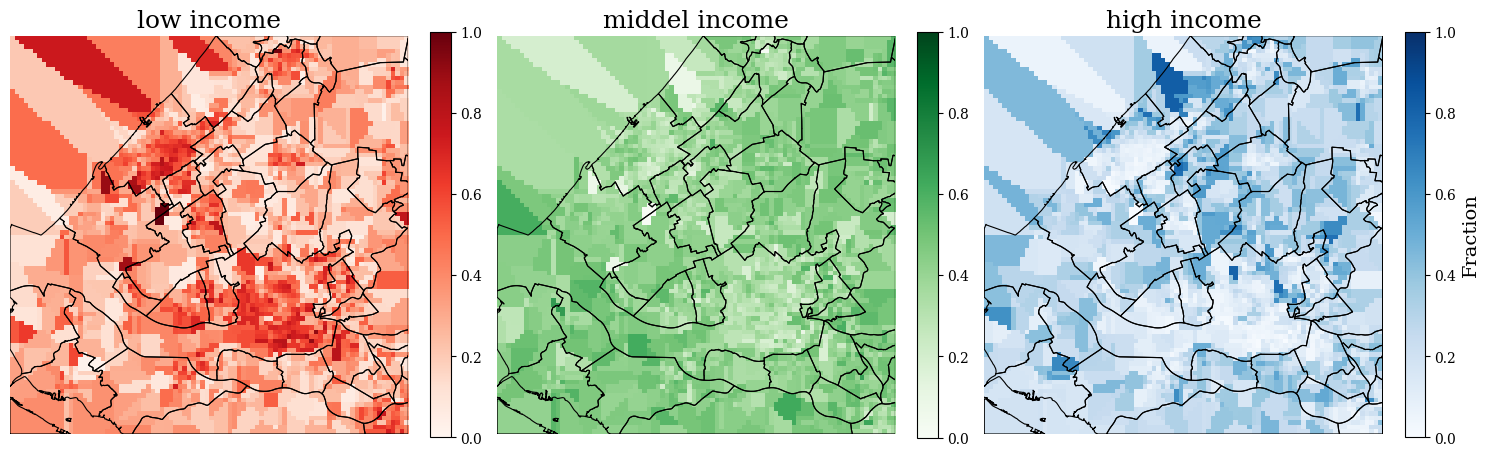

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, phi in enumerate(mirror_2015):
    minx, miny, maxx, maxy = bounds[0]

    # Create a bounding box polygon for clipping
    bbox = box(minx, miny, maxx, maxy)

    # Clip the gemeenten geometries to the bounding box
    gemeenten_clipped = gemeenten_all[0].copy()
    im = axes[i].imshow(phi, origin="lower", extent=[minx, maxx, miny, maxy], cmap=cmap_colors[i], vmin=0, vmax=1)
    
    gemeenten_clipped.geometry = gemeenten_clipped.geometry.intersection(bbox)
    gemeenten_clipped.boundary.plot(ax=axes[i], color="black", linewidth=0.8)

    cbar = fig.colorbar(im, ax=axes[i], fraction=0.046)
    if i==2:
        cbar.set_label("Fraction", fontsize = ax_size)
    

    axes[i].set_title(f"{species[i]}", fontsize=title_size+2)
    # axes[i].set_xlabel("x", fontsize=ax_size)
    # axis = off
    axes[i].set_axis_off()
    

plt.tight_layout()
plt.show()